# Handling a long input

In [9]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

Find a long video you'd like to process and put it on GCS:

In [10]:
video_uri = "gs://cloud-samples-data/generative-ai/video/animals.mp4"

In [17]:
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_google_vertexai import ChatVertexAI

human_part = {"type": "text", "text": "Provide a summary of the video."}

def _create_input_messages(*, video_uri: str, chunks: int = 5, interval_secs: int = 10):
    video_parts = []
    for start_offset in range(chunks):
        part = {
            "type": "media",
            "file_uri": video_uri,
            "mime_type": "video/mp4",
            "video_metadata": {
                "start_offset": {"seconds": start_offset * interval_secs},
                "end_offset": {"seconds": (start_offset + 1) * interval_secs},
            },
        }

        video_parts.append(part)

    return [[HumanMessage(content=[human_part, vp])] for vp in video_parts]

input_messages = _create_input_messages(video_uri=video_uri)
llm = ChatVertexAI(model="gemini-2.5-flash")
map_chain = llm | StrOutputParser()
summaries = map_chain.batch(input_messages, config={"max_concurrency": 3})
summaries

['This video begins with serene shots of nature, featuring the intricate pattern of a giraffe\'s fur and close-ups of dewy leaves glistening in the sunlight. It then transitions to a specialized, spherical "Google Photos" device holding a smartphone, partially submerged in water. A voiceover explains that the creators were "inspired by Disney\'s Zootopia" and the way "the animals use technology" in the movie, implying a connection between imaginative technology use and Google Photos\' capabilities, possibly for capturing moments in various environments.',
 'This video is a promotional piece for the Disney movie "Zootopia," featuring an event held at the Los Angeles Zoo. Inspired by the film\'s premise of animals living in a modern, technologically advanced society, the organizers explore what it would be like if real-world zoo animals used technology.\n\nRico Farmer, Brand and Experiential Marketing Manager, explains that they set up interactive screens and cameras in animal enclosures

In [ ]:
from langchain_core.runnables import RunnableLambda

# Create Map Procedure for the data
create_inputs_chain = RunnableLambda(lambda x: _create_input_messages(**x))
map_step_chain = create_inputs_chain | RunnableLambda(lambda x: map_chain.batch(x, config={"max_concurrency": 3}))
summaries = map_step_chain.invoke({"video_uri": video_uri})

Let's define a function to merge summaries together:

In [22]:
from langchain_core.prompts import PromptTemplate

def _merge_summaries(summaries: list[str], interval_secs: int = 10, **kwargs) -> str:
    sub_summaries = []
    for i, summary in enumerate(summaries):
        sub_summary = (
            f"Summary from sec {i * interval_secs} to sec {(i + 1) * interval_secs}:"
            f"\n{summary}\n"
        )
        sub_summaries.append(sub_summary)
    return "".join(sub_summaries)

reduce_prompt = PromptTemplate.from_template(
    "You are given a list of summaries that "
    "of a video splitted into sequential pieces.\n"
    "SUMMARIES:\n{summaries}"
    "Based on that, prepare a summary of a whole video."
)

reduce_chain = RunnableLambda(lambda x: _merge_summaries(**x)) | reduce_prompt | llm | StrOutputParser()
final_summary = reduce_chain.invoke({"summaries": summaries})

In [23]:
print(final_summary)

The video details a unique promotional initiative by Google Photos, inspired by Disney's "Zootopia," where technology is brought into a zoo setting to capture animal interactions. It begins with serene nature shots and introduces a specialized, spherical Google Photos device, hinting at its capability to capture moments in diverse environments. A voiceover explains the inspiration came from "Zootopia" and its depiction of animals using technology.

The video then elaborates on a promotional event held at the Los Angeles Zoo, where interactive screens and cameras were placed in animal enclosures. Rico Farmer, Brand and Experiential Marketing Manager, highlights how various animals—including monkeys, birds, elephants, giraffes, bears, and a Sumatran tiger named CJ—curiously interacted with these devices. The screens playfully displayed animal "selfies" with filters, encouraging viewers to engage further with the "Zootopia" movie and the animals' stories.

A central element is the Google 

Let's implement a reduce step that merges intermediatesummaries together:

In [24]:
from langchain.chains import LLMChain

reduce_chain = RunnableLambda(lambda x: _merge_summaries(**x)) | LLMChain(llm=llm, prompt=reduce_prompt, output_parser=StrOutputParser())

/var/folders/g9/r5wkd4y16551311v_l_3k9q00000gn/T/ipykernel_8156/330329033.py:3: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  reduce_chain = RunnableLambda(lambda x: _merge_summaries(**x)) | LLMChain(llm=llm, prompt=reduce_prompt, output_parser=StrOutputParser())


In [25]:
from langchain_core.runnables import RunnablePassthrough

final_chain = (
    RunnablePassthrough.assign(summaries=map_step_chain).assign(final_summary=reduce_chain)
    | RunnableLambda(lambda x: x["final_summary"])
)

result = final_chain.invoke({"video_uri": video_uri, "interval_secs": 5, "chunks": 5})

In [26]:
print(result)

{'summaries': 'Summary from sec 0 to sec 5:\nThe video features a series of close-up shots showcasing natural elements. It begins with a detailed view of a giraffe\'s patterned skin, followed by vibrant green leaves covered in glistening water droplets, backlit by the sun, creating a beautiful bokeh effect. One shot highlights a single water droplet clinging to the tip of a leaf. Throughout the visuals, a gentle and calming acoustic instrumental track plays. The overall impression is one of natural beauty, tranquility, and detailed observation.\nSummary from sec 5 to sec 10:\nThe video showcases a project by Google Photos inspired by Disney\'s Zootopia, where animals use technology. To capture intimate wildlife photos without disturbing the animals, Google Photos created a specialized underwater camera rig designed to look like part of the natural environment.\n\nA smartphone (specifically a Nexus device) was placed inside a waterproof casing within this rig. The rig was then submerged

## Using LangGraph

Let's implement the same logic using LangGraph:

In [ ]:
import operator
from typing_extensions import TypedDict
from typing import Annotated, List
from langgraph.types import  # Update Deprecation
from langgraph.graph import StateGraph, END, START

class AgentState(TypedDict):
    video_uri: str
    chunks: int
    interval_secs: int
    summaries: Annotated[List[str], operator.add]
    final_summary: str

class _ChunkState(TypedDict):
    video_uri: str
    start_offset: int
    interval_secs: int

human_part = {"type": "text", "text": "Provide a summary of the video."}

async def _summarise_video_chunk(state: _ChunkState):
    start_offset = state["start_offset"]
    interval_secs = state["interval_secs"]
    video_part = {
        "type": "media", "file_uri": state["video_uri"], "mime_type": "video/mp4",
        "video_metadata": {
            "start_offset": {"seconds": start_offset * interval_secs},
            "end_offset": {"seconds": (start_offset + 1) * interval_secs}
        }
    }

    response = await llm.ainvoke([HumanMessage(content=[human_part, video_part])])
    return {"summaries": [response.content]}

def _map_summaries(state: AgentState):
    chunks = state["chunks"]
    payloads = [
        {
            "video_uri": state["video_uri"],
            "interval_secs": state["interval_secs"],
            "start_offset": i
        } for i in range(state["chunks"])
    ]
    return [Send("summarise_video_chunk", payload) for payload in payloads]

async def _generate_final_summary(state: AgentState):
    summary = _merge_summaries(
        summaries = state["summaries"], interval_secs=state["interval_secs"]
    )
    final_summary = await (reduce_prompt | llm | StrOutputParser()).ainvoke({"summaries": summary})
    return {"final_summary": final_summary}

graph = StateGraph(AgentState)
graph.add_node("summarise_video_chunk", _summarise_video_chunk)
graph.add_node("generate_final_summary", _generate_final_summary)

graph.add_conditional_edges(START, _map_summaries, ["summarise_video_chunk"])
graph.add_edge("summarise_video_chunk", "generate_final_summary")
graph.add_edge("generate_final_summary", END)

app = graph.compile()

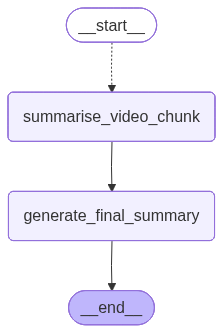

In [34]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [35]:
result = await app.ainvoke(
    {"video_uri": video_uri, "chunks": 5, "interval_secs": 5},
    {"max_concurrency": 3}
)
print(result["final_summary"])

The video opens with serene close-up shots of lush green foliage, sparkling with water droplets and sunlight, subtly hinting at its theme with a brief blurred pattern resembling a giraffe's hide. It then transitions to present a humorous and speculative concept from Google Photos, inspired by Disney's Zootopia. The core idea imagines a future where animals use specially designed, nature-friendly cameras to capture their own "once-in-a-lifetime moments" and "perfect selfies," leveraging Google Photos' AI for organization. This playful concept is visually reinforced by animated Zootopia characters, Nick Wilde and Judy Hopps, taking a selfie together with a selfie stick, as a voiceover discusses the idea of animals using human technology. The narrative then shifts to the Los Angeles Zoo, where Rico Farmer, Brand and Experiential Marketing Manager, explains how the zoo's animals inspired Zootopia's characters. The video culminates with real giraffes and a Sumatran tiger (CJ) at the zoo, sh

In [37]:
async for step in app.astream(
    {"video_uri": video_uri, "chunks": 5, "interval_secs": 5},
    {"recursion_limit": 10},
):
    print(list(step.keys()))

['summarise_video_chunk']
['summarise_video_chunk']
['summarise_video_chunk']
['summarise_video_chunk']
['summarise_video_chunk']
['generate_final_summary']


Let's look at the final summary:

In [38]:
result["final_summary"]

'The video opens with serene close-up shots of lush green foliage, sparkling with water droplets and sunlight, subtly hinting at its theme with a brief blurred pattern resembling a giraffe\'s hide. It then transitions to present a humorous and speculative concept from Google Photos, inspired by Disney\'s Zootopia. The core idea imagines a future where animals use specially designed, nature-friendly cameras to capture their own "once-in-a-lifetime moments" and "perfect selfies," leveraging Google Photos\' AI for organization. This playful concept is visually reinforced by animated Zootopia characters, Nick Wilde and Judy Hopps, taking a selfie together with a selfie stick, as a voiceover discusses the idea of animals using human technology. The narrative then shifts to the Los Angeles Zoo, where Rico Farmer, Brand and Experiential Marketing Manager, explains how the zoo\'s animals inspired Zootopia\'s characters. The video culminates with real giraffes and a Sumatran tiger (CJ) at the z